In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import scikit_posthocs as sp

In [2]:
df = pd.read_csv("/Users/joepsticker/MachineLearning/Smart-Toilet/data/raw/dataset 1.csv")

In [3]:
df

,home,seat,user_id,session,window,urinate,normal,no,hard,soft,weight,heartrate,temperature,comx,comy
0,8868fe4de610d348,d6b7a54f96ce39a4,eefbc3f27093becc,2025-07-27-18-11-28,1,1,1,0,0,0,46.610289,NaN,35.327988,0.029312,0.560280
1,8868fe4de610d348,d6b7a54f96ce39a4,eefbc3f27093becc,2025-07-27-18-11-28,2,1,1,0,0,0,46.573018,67.964602,35.327988,0.029735,0.562222
2,8868fe4de610d348,d6b7a54f96ce39a4,eefbc3f27093becc,2025-07-27-18-11-28,3,1,1,0,0,0,46.528367,64.537815,35.327988,0.029902,0.563786
3,8868fe4de610d348,d6b7a54f96ce39a4,eefbc3f27093becc,2025-07-27-18-11-28,4,1,1,0,0,0,46.425224,62.439024,35.327988,0.031608,0.568907
4,8868fe4de610d348,d6b7a54f96ce39a4,eefbc3f27093becc,2025-07-27-18-11-28,5,1,1,0,0,0,46.325638,60.472441,35.327988,0.033335,0.570972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16383,929b9daaa2c181f9,d6b7a54f96ce39a4,28d3731c392ca13c,2025-07-10-08-08-24,16,0,0,0,0,0,40.344195,NaN,34.722966,0.023062,0.855267
16384,929b9daaa2c181f9,d6b7a54f96ce39a4,28d3731c392ca13c,2025-07-10-08-08-24,17,0,0,0,0,0,NaN,NaN,34.722966,NaN,NaN
16385,929b9daaa2c181f9,d6b7a54f96ce39a4,28d3731c392ca13c,2025-07-10-08-08-24,18,0,0,0,0,0,NaN,NaN,34.722966,NaN,NaN
16386,929b9daaa2c181f9,d6b7a54f96ce39a4,28d3731c392ca13c,2025-07-10-08-08-24,19,0,0,0,0,0,NaN,NaN,34.722966,NaN,NaN


In [4]:
df.shape

(16388, 15)

In [5]:
df.isna().sum().sort_values(ascending=False)

heartrate      4826
weight         2619
comx           2619
comy           2619
temperature     647
home              0
seat              0
user_id           0
session           0
window            0
urinate           0
normal            0
no                0
hard              0
soft              0
dtype: int64

In [6]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.round(2)

heartrate      29.45
weight         15.98
comx           15.98
comy           15.98
temperature     3.95
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(15)

In [8]:
df["heartrate"] = df["heartrate"].fillna(
    df.groupby("user_id")["heartrate"].transform("mean")
)

In [9]:
df[["no","urinate","normal","hard","soft"]].sum(axis=1).value_counts()

1    9280
2    5502
0    1300
3     306
Name: count, dtype: int64

In [10]:
session_buttons = df.groupby("session")[["no","urinate","normal","hard","soft"]].max()

In [11]:
session_buttons["defecation"] = (
    (session_buttons["normal"] == 1) |
    (session_buttons["hard"] == 1) |
    (session_buttons["soft"] == 1)
).astype(int)

In [12]:
session_buttons[
    (session_buttons["urinate"] == 0) &
    (session_buttons["defecation"] == 0) &
    (session_buttons["no"] == 0)
][["urinate","normal","hard","soft", "no"]].head(20)

,urinate,normal,hard,soft,no
session,,,,,
2025-06-24-17-48-40,0,0,0,0,0
2025-06-24-21-05-42,0,0,0,0,0
2025-06-26-06-36-32,0,0,0,0,0
2025-06-27-01-06-47,0,0,0,0,0
2025-06-30-15-15-52,0,0,0,0,0
2025-06-30-16-58-54,0,0,0,0,0
2025-07-01-22-11-11,0,0,0,0,0
2025-07-02-05-10-31,0,0,0,0,0
2025-07-02-08-24-22,0,0,0,0,0


In [13]:
# Maar 1 sessie met "Aandrang". Dimensie verwaarlozen
session_buttons[["no"]].value_counts()

no
0     343
1       1
Name: count, dtype: int64

In [14]:
session_buttons[["urinate","normal","hard","soft"]].sum()

urinate    279
normal      50
hard        14
soft         8
dtype: int64

In [15]:
session_buttons["target"] = np.select(
    [
        (session_buttons["urinate"] == 1) & (session_buttons["defecation"] == 0),
        (session_buttons["urinate"] == 0) & (session_buttons["defecation"] == 1),
        (session_buttons["urinate"] == 1) & (session_buttons["defecation"] == 1)
    ],
    [1, 2, 3],
    default=np.nan
)

In [16]:
session_buttons["target"].value_counts()

target
1.0    231
3.0     48
2.0     22
Name: count, dtype: int64

In [17]:
session_features = df.groupby("session").agg(
    weight_mean=("weight","mean"),
    weight_std=("weight","std"),
    weight_min=("weight","min"),
    weight_max=("weight","max"),

    heartrate_mean=("heartrate","mean"),
    heartrate_max=("heartrate","max"),

    temperature_mean=("temperature","mean"),

    comx_mean=("comx","mean"),
    comx_std=("comx","std"),
    comx_min=("comx","min"),
    comx_max=("comx","max"),

    comy_mean=("comy","mean"),
    comy_std=("comy","std"),
    comy_min=("comy","min"),
    comy_max=("comy","max"),

    session_duration=("window","count"),
    user_id=("user_id","first")
)

session_features

,weight_mean,weight_std,weight_min,weight_max,heartrate_mean,heartrate_max,temperature_mean,comx_mean,comx_std,comx_min,comx_max,comy_mean,comy_std,comy_min,comy_max,session_duration,user_id
session,,,,,,,,,,,,,,,,,
2025-06-24-13-58-44,40.581649,0.464951,39.845327,40.962890,94.703482,94.703482,33.589549,0.001839,0.007676,-0.008077,0.009597,0.852721,0.004523,0.848444,0.864772,14,28d3731c392ca13c
2025-06-24-14-56-44,42.309031,0.240172,41.816570,42.628104,74.342223,92.530120,36.123236,0.093307,0.002470,0.090497,0.099114,0.752248,0.008316,0.733092,0.763849,14,aeda476877496f18
2025-06-24-17-25-59,41.851762,0.668527,40.933702,42.917295,90.048984,94.703482,35.368088,0.005366,0.005444,-0.010873,0.012727,0.805331,0.034476,0.786136,0.901375,18,28d3731c392ca13c
2025-06-24-17-48-40,43.550947,0.600166,42.725939,44.316518,74.536107,77.702606,35.856104,0.063729,0.006948,0.053896,0.071137,0.790899,0.002714,0.786912,0.794347,11,aeda476877496f18
2025-06-24-21-05-42,41.869678,0.509422,40.908615,44.004179,71.227482,89.314402,36.053727,-0.001889,0.022066,-0.033205,0.088721,0.736337,0.024057,0.690486,0.780290,236,aeda476877496f18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-06-23-56-57,45.498020,0.080517,45.380403,45.604991,75.290101,76.039604,34.568533,0.019146,0.006339,0.012024,0.028939,0.683813,0.002964,0.679247,0.686893,12,eefbc3f27093becc
2025-08-07-06-47-16,59.160439,1.576460,58.610841,64.625975,82.367640,91.567552,35.088557,0.004886,0.003784,0.002859,0.017785,0.569162,0.004832,0.562723,0.580823,17,56e8788ef8847530
2025-08-07-07-09-37,60.846274,0.354116,60.315268,61.292713,81.844282,88.275862,34.501937,-0.068684,0.012029,-0.086468,-0.050615,0.682934,0.005994,0.671879,0.689014,22,eefbc3f27093becc


In [18]:
# Add target to df

session_df = session_features.merge(
    session_buttons["target"],
    left_index=True,
    right_index=True
)

session_df.head()
session_df["target"].value_counts()


target
1.0    231
3.0     48
2.0     22
Name: count, dtype: int64

In [19]:
#EDA per target cat
session_df.groupby("target")["session_duration"].mean()

target
1.0     32.450216
2.0     87.500000
3.0    118.062500
Name: session_duration, dtype: float64

In [20]:
session_df.groupby("target")[["weight_mean", "weight_min", "weight_max"]].mean()

,weight_mean,weight_min,weight_max
target,,,
1.0,50.107220,48.940988,52.062128
2.0,58.582829,56.263184,61.340394
3.0,52.118960,48.358937,56.787622


In [21]:
session_df.groupby("target")[["comx_std","comy_std"]].mean()

,comx_std,comy_std
target,,
1.0,0.014562,0.012896
2.0,0.052990,0.050134
3.0,0.040083,0.048765


In [22]:
#Session Duration per Target Category:
session_df.groupby("target")["session_duration"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
1.0,231.0,32.450216,63.508205,1.0,8.00,16.0,32.00,586.0
2.0,22.0,87.500000,53.854964,7.0,55.25,85.0,116.25,190.0
3.0,48.0,118.062500,116.261153,7.0,31.00,77.0,166.50,544.0


In [23]:
#Every group has outliers of 20kg+

session_df["weight_drop"] = (
    session_df["weight_max"] - session_df["weight_min"]
)

session_df.groupby("target")["weight_drop"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
1.0,224.0,3.121141,5.335794,0.000000,0.259818,0.742122,2.696650,32.540411
2.0,22.0,5.077210,6.004086,0.079483,1.623716,3.583990,5.700913,22.842160
3.0,48.0,8.428685,6.262623,0.437249,3.311908,7.059515,11.946987,23.972491


In [24]:
#Movement as std of Centre of Mass

session_df.groupby("target")[["comx_std","comy_std"]].mean()


,comx_std,comy_std
target,,
1.0,0.014562,0.012896
2.0,0.052990,0.050134
3.0,0.040083,0.048765


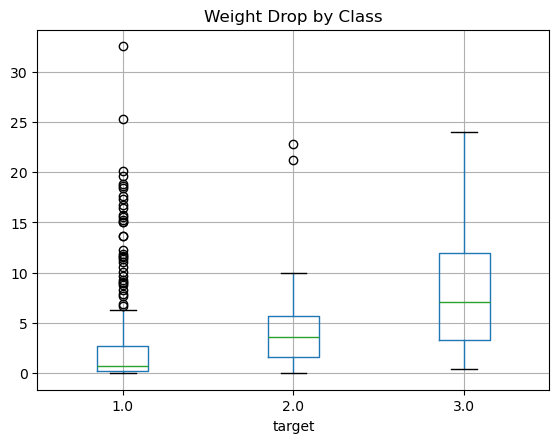

In [25]:
session_df.boxplot(column="weight_drop", by="target")
plt.title("Weight Drop by Class")
plt.suptitle("")
plt.show()

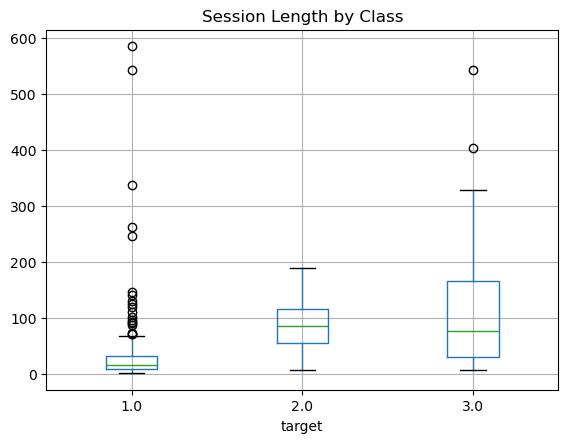

In [26]:
session_df.boxplot(column="session_duration", by="target")
plt.title("Session Length by Class")
plt.suptitle("")
plt.show()


In [27]:
session_df.head()
session_df.info()

<class 'pandas.DataFrame'>
Index: 344 entries, 2025-06-24-13-58-44 to 2025-08-07-12-15-52
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   weight_mean       335 non-null    float64
 1   weight_std        323 non-null    float64
 2   weight_min        335 non-null    float64
 3   weight_max        335 non-null    float64
 4   heartrate_mean    344 non-null    float64
 5   heartrate_max     344 non-null    float64
 6   temperature_mean  341 non-null    float64
 7   comx_mean         335 non-null    float64
 8   comx_std          323 non-null    float64
 9   comx_min          335 non-null    float64
 10  comx_max          335 non-null    float64
 11  comy_mean         335 non-null    float64
 12  comy_std          323 non-null    float64
 13  comy_min          335 non-null    float64
 14  comy_max          335 non-null    float64
 15  session_duration  344 non-null    int64  
 16  user_id           344 non-

### Temp df with removed Null values

In [28]:
session_df[["session_duration","target"]].isna().sum()

session_duration     0
target              43
dtype: int64

In [29]:
df_test = session_df[["session_duration","target"]].dropna()

In [30]:
#Kruskal-Wallis for significant differences in session duration between classes

group1 = session_df[session_df["target"] == 1]["session_duration"]
group2 = session_df[session_df["target"] == 2]["session_duration"]
group3 = session_df[session_df["target"] == 3]["session_duration"]

stat, p = kruskal(group1, group2, group3)

print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("There are significant differences in session duration between the classes.")

Statistic: 66.66094128178796
p-value: 3.3478078349670294e-15
There are significant differences in session duration between the classes.


In [31]:
sp.posthoc_dunn(
    df_test,
    val_col="session_duration",
    group_col="target",
    p_adjust="bonferroni"
)

,1.0,2.0,3.0
1.0,1.000000e+00,0.000002,6.131275e-12
2.0,1.922289e-06,1.000000,1.000000e+00
3.0,6.131275e-12,1.000000,1.000000e+00


Poo and both are not significantly different in regards to duration

In [32]:
session_target = session_df.groupby("session")["target"].first()
toilet_df = session_features.join(session_target)

In [33]:
toilet_df[["session_duration","target"]].isna().sum()

session_duration     0
target              43
dtype: int64

In [34]:
toilet_df = toilet_df.dropna()

In [35]:
toilet_df.to_parquet(
    "../data/processed/toilet_df.parquet",
    engine="pyarrow"
)